# Лабораторная работа №3
## Проверка и улучшение моделей машинного обучения

Продолжаем задачу из ЛР №2: прогноз стоимости квартиры.

В этой работе важен не поиск «самой умной» модели, а **правильная организация ML-эксперимента**:

**данные → train/test → preprocessing → несколько моделей → cross-validation → настройка гиперпараметра → финальная проверка.**

Будем сравнивать:
- Linear Regression;
- Ridge;
- kNN Regression;
- Decision Tree Regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 10)
pd.set_option("display.max_rows", 10)

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# фиксируем seed, чтобы все запуски воспроизводились
RANDOM_STATE = 42

## 1. Загрузка данных

Загрузите `ai_housing_lab2.csv`, который использовался в ЛР №2.

In [2]:
df = pd.read_csv("ai_housing_lab2.csv")
display(df.head())
print(df.shape)
print(df.dtypes)

# пропусков вроде нет, но проверим заранее
print("пропусков:", df.isnull().sum().sum())
print("дубликатов:", df.duplicated().sum())

,Area,Rooms,Floor,BuildingAge,MetroMinutes,District,Renovation,PriceMillion
0,48.9,1,22,36,10.4,Центр,Обычный,14.40
1,102.9,3,8,13,5.9,Центр,Обычный,30.35
2,82.7,3,2,43,21.3,Центр,Без ремонта,17.19
3,71.3,2,17,51,10.3,Юг,Хороший,17.58
4,69.5,3,23,34,12.0,Юг,Обычный,15.59


(650, 8)
Area            float64
Rooms             int64
Floor             int64
BuildingAge       int64
MetroMinutes    float64
District            str
Renovation          str
PriceMillion    float64
dtype: object
пропусков: 0
дубликатов: 0


### Задание 1
Укажите:
1. целевой признак;
2. числовые признаки;
3. категориальные признаки;
4. почему `PriceMillion` нельзя включать в `X`.

Целевой это PriceMillion, цена квартиры в миллионах. Числовые это Area, Rooms, Floor, BuildingAge, MetroMinutes, категориальные это District и Renovation.

PriceMillion нельзя оставлять в X потому что это ответ, а не признак. Модель тогда просто скопирует его из входа и метрики будут идеальные, а на новых объектах такого столбца не будет.

In [3]:
# решил проверить что будет если оставить цену в признаках
leak_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["Area", "Rooms", "Floor", "BuildingAge", "MetroMinutes", "PriceMillion"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["District", "Renovation"])
])

leak_pipe = Pipeline([("preprocessor", leak_preprocessor), ("model", LinearRegression())])

X_leak_train, X_leak_test, y_leak_train, y_leak_test = train_test_split(
    df.copy(), df["PriceMillion"], test_size=0.20, random_state=RANDOM_STATE
)

leak_pipe.fit(X_leak_train, y_leak_train)
leak_pred = leak_pipe.predict(X_leak_test)

print("MAE с утечкой:", round(mean_absolute_error(y_leak_test, leak_pred), 4))
print("R2  с утечкой:", round(r2_score(y_leak_test, leak_pred), 4))

MAE с утечкой: 0.0
R2  с утечкой: 1.0


Вот так и вышло. Модель ничего не выучила, а просто достаёт ответ из входа. Хорошо что проверил, а то так спокойно записал бы в отчёт что модель отличная.

Сначала поставил туда Ridge и получил MAE 0.031, то есть штраф утечку совсем не спас, только чуть пригладил.

## 2. Train/test: фиксируем честную финальную проверку

In [4]:
X = df.drop(columns="PriceMillion")
y = df["PriceMillion"]

numeric_features = ["Area", "Rooms", "Floor", "BuildingAge", "MetroMinutes"]
categorical_features = ["District", "Renovation"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (520, 7)
Test : (130, 7)


In [5]:
# и сразу посчитал baseline из ЛР2, чтобы было с чем сравнивать
base_pred = np.full(len(y_test), y_train.mean())

print("baseline MAE :", round(mean_absolute_error(y_test, base_pred), 3))
print("baseline RMSE:", round(mean_squared_error(y_test, base_pred) ** 0.5, 3))
print("baseline R2  :", round(r2_score(y_test, base_pred), 3))

baseline MAE : 6.555
baseline RMSE: 7.653
baseline R2  : -0.006


### Задание 2
Почему тестовую выборку следует оставить в стороне до финальной проверки моделей? Что произойдёт, если многократно подбирать модель по результату именно на test?

Потому что test это финальная проверка и использовать его можно только один раз. Если смотреть на него много раз, я начну выбирать модель которая просто повезла на этих 130 объектах, и метрика будет врать в лучшую сторону. По сути test перестанет быть test и станет ещё одной частью обучения.

## 3. Preprocessing и масштабирование

Для числовых признаков используем `StandardScaler`. Категориальные признаки преобразуем через `OneHotEncoder`.

Всё помещаем в `Pipeline`, чтобы преобразования обучались **только на соответствующей обучающей части данных**.

In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [7]:
# посмотрел какие вообще масштабы у числовых признаков
display(df[numeric_features].agg(["min", "max", "mean", "std"]).round(2))

,Area,Rooms,Floor,BuildingAge,MetroMinutes
min,28.20,1.00,1.00,0.00,2.10
max,144.90,6.00,25.00,60.00,35.00
mean,87.90,3.14,12.56,29.39,18.37
std,33.01,1.36,7.36,17.17,9.58


Разница огромная, Area от 28 до 145 а Rooms это 1 до 6. Без масштабирования они будут сравниваться вообще не по смыслу а по единицам измерения.

### Задание 3
Объясните:
- зачем масштабировать числовые признаки;
- для каких из четырёх моделей масштабирование особенно важно;
- почему preprocessing помещён внутрь Pipeline, а не выполнен один раз до cross-validation.

Масштабировать нужно потому что признаки измеряются в разном, и без этого сравнивать их друг с другом бессмысленно.

Для kNN это критично, он работает по расстояниям и Area с размахом 117 перевесит Rooms с размахом 5, остальные признаки почти не повлияют. Для Ridge тоже важно, потому что alpha штрафует величину коэффициента а не его влияние на прогноз. Дереву вообще без разницы, там всё через пороги идёт.

Pipeline нужен чтобы scaler обучался только на тренировочной части каждого фолда. Если обучить его один раз на всём датасете, то в cross-validation он уже видел валидационные объекты, это утечка и метрики будут завышены.

## 4. Четыре модели в одинаковых условиях

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=5,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print(list(pipelines))

['LinearRegression', 'Ridge', 'kNN', 'DecisionTree']


preprocessor тут один на все модели и специально не копировал его руками, иначе это уже будет не сравнение моделей а сравнение способов подготовки данных.

## 5. Cross-validation

На обучающей выборке выполним 5-кратную cross-validation. Для каждой модели получим средние MAE, RMSE и R², а также разброс MAE между фолдами.

In [9]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )

    cv_rows.append({
        "Model": name,
        "CV_MAE_mean": -scores["test_MAE"].mean(),
        "CV_MAE_std": scores["test_MAE"].std(),
        "CV_RMSE_mean": -scores["test_RMSE"].mean(),
        "CV_R2_mean": scores["test_R2"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
display(cv_results.round(3))

,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean
1,Ridge,1.972,0.130,2.463,0.884
0,LinearRegression,1.975,0.129,2.464,0.884
3,DecisionTree,2.639,0.110,3.299,0.791
2,kNN,2.740,0.221,3.433,0.772


In [10]:
# ещё посмотрел по каждому фолду отдельно, так стабильность виднее
fold_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)

    for fold, score in enumerate(scores["test_MAE"], start=1):
        fold_rows.append({"Model": name, "Fold": fold, "MAE": -score})

display(
    pd.DataFrame(fold_rows)
    .pivot(index="Model", columns="Fold", values="MAE")
    .round(3)
)

Fold,1,2,3,4,5
Model,,,,,
DecisionTree,2.771,2.569,2.713,2.679,2.463
LinearRegression,2.163,1.906,1.835,2.092,1.877
Ridge,2.165,1.907,1.835,2.086,1.869
kNN,2.970,2.829,2.935,2.400,2.568


### Задание 4
1. Какая модель имеет наименьший средний MAE?
2. Какая показывает наибольший R²?
3. Что означает `CV_MAE_std`?
4. Всегда ли модель с лучшим средним результатом одновременно самая стабильная?

Наименьший MAE у Ridge 1.972, но LinearRegression 1.975, то есть разница 0.003 это вообще ничего, я бы даже не стал объявлять победителя. R2 максимальный там же 0.884.

CV_MAE_std это разброс MAE между фолдами, то есть насколько результат зависит от того какие данные попали в проверку. Чем меньше, тем стабильнее.

И нет, не всегда совпадает. DecisionTree самый стабильный 0.110, но качество хуже. А kNN наоборот, и хуже всех по MAE, и разброс самый большой 0.221.

## 6. Визуальное сравнение

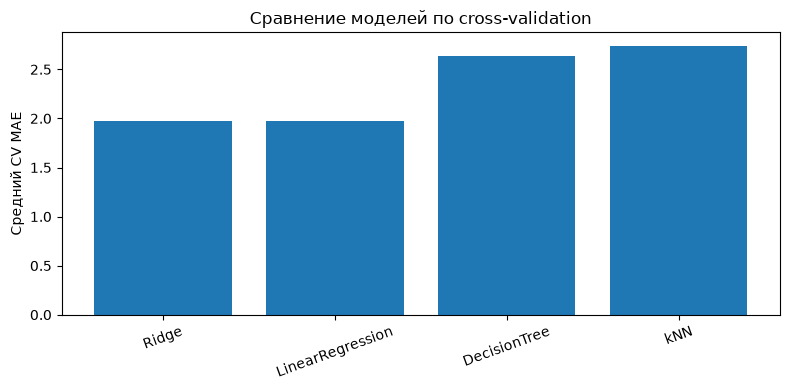

In [11]:
plot_df = cv_results.sort_values("CV_MAE_mean")

plt.figure(figsize=(8, 4))
plt.bar(plot_df["Model"], plot_df["CV_MAE_mean"])
plt.ylabel("Средний CV MAE")
plt.title("Сравнение моделей по cross-validation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

На графике первые два столбца вообще не отличить, разница меньше толщины линии. Так что график тут только чтобы увидеть что есть две группы, а выбирать надо по таблице.

### Задание 5
По таблице и графику выберите две наиболее перспективные модели. Обоснуйте выбор не только одним числом, но и стабильностью результата.

Беру Ridge и LinearRegression. У них лучший MAE и R2, и разброс небольшой, 0.13. Разрыв до дерева 0.664 это уже не шум.

DecisionTree хоть и стабильнее всех, но качество на треть хуже, ему просто не хватает данных чтоб что-то поймать. kNN худший и самый нестабильный, что кстати подтверждает мысль про то что модели на расстояниях у нас не очень.

## 7. Настройка одного гиперпараметра

Настроим `alpha` у Ridge. Это коэффициент регуляризации. Используем `GridSearchCV`, причём тестовая выборка по-прежнему не участвует в подборе.

In [12]:
ridge_pipe = pipelines["Ridge"]

param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

grid.fit(X_train, y_train)

print("Лучший alpha:", grid.best_params_["model__alpha"])
print("Лучший CV MAE:", round(-grid.best_score_, 3))

Лучший alpha: 1.0
Лучший CV MAE: 1.972


In [13]:
# глянул что показал перебор по каждому alpha, а не только победителя
alpha_results = pd.DataFrame(grid.cv_results_)[
    ["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]
].copy()

alpha_results["MAE"] = -alpha_results["mean_test_score"]

display(alpha_results.set_index("param_model__alpha").round(4))

,mean_test_score,std_test_score,rank_test_score,MAE
param_model__alpha,,,,
0.01,-1.9746,0.1289,3,1.9746
0.10,-1.9744,0.1289,2,1.9744
1.00,-1.9723,0.1296,1,1.9723
10.00,-1.9750,0.1392,4,1.9750
100.00,-2.3341,0.1754,5,2.3341


### Задание 6
Сравните лучший Ridge с исходным `alpha=1.0`. Сильно ли изменился результат? Почему подбор гиперпараметра тоже должен выполняться без использования test?

Лучшее alpha = 1.0, то есть ровно то же что было по умолчанию. То есть настройка не дала вообще ничего.

Значения от 0.01 до 10 отличаются в пределах 0.003, это шум. А вот на 100 MAE вырос до 2.334, там уже явно недообучение. Так что вывод такой что перебор гиперпараметров не обязан улучшать результат, и это нормально.

Подбирать надо не по test по той же причине что и раньше, иначе test тоже станет частью обучения и финальная цифра ничего не значит.

## 8. Финальная проверка на test

Теперь один раз оцениваем модели на отложенной тестовой выборке. Для Ridge используем лучший вариант из `GridSearchCV`.

In [14]:
final_models = {
    "LinearRegression": pipelines["LinearRegression"],
    "Ridge_best": grid.best_estimator_,
    "kNN": pipelines["kNN"],
    "DecisionTree": pipelines["DecisionTree"]
}

test_rows = []

for name, model in final_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    test_rows.append({
        "Model": name,
        "Test_MAE": mean_absolute_error(y_test, pred),
        "Test_RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "Test_R2": r2_score(y_test, pred)
    })

test_results = pd.DataFrame(test_rows).sort_values("Test_MAE")
display(test_results.round(3))

,Model,Test_MAE,Test_RMSE,Test_R2
1,Ridge_best,1.838,2.328,0.907
0,LinearRegression,1.840,2.329,0.907
3,DecisionTree,2.602,3.270,0.816
2,kNN,2.797,3.468,0.794


### Задание 7
Сравните результаты cross-validation и test. Совпала ли модель-лидер? Если нет — является ли это обязательно ошибкой?

Порядок совпал полностью, Ridge, LinearRegression, DecisionTree, kNN. Но сами числа разные, на test MAE 1.838 против 1.972 в CV.

Это не ошибка. Оценка считается на разном объёме, плюс 130 объектов могли просто повезти. Расхождение 0.134 при разбросе между фолдами 0.130, то есть это обычный шум.

## 9. Почему один train/test split может вводить в заблуждение

Повторим только Linear Regression при трёх вариантах размера тестовой выборки: 50%, 20% и 5%.

In [15]:
split_rows = []

for test_size in [0.50, 0.20, 0.05]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_STATE
    )

    pipe = pipelines["LinearRegression"]
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    split_rows.append({
        "Test_size": test_size,
        "Train_n": len(X_tr),
        "Test_n": len(X_te),
        "MAE": mean_absolute_error(y_te, pred),
        "R2": r2_score(y_te, pred)
    })

split_results = pd.DataFrame(split_rows)
display(split_results.round(3))

,Test_size,Train_n,Test_n,MAE,R2
0,0.50,325,325,2.004,0.885
1,0.20,520,130,1.840,0.907
2,0.05,617,33,1.605,0.905


In [16]:
# вот это меня удивило: та же модель, тот же test_size, только разный random_state
seed_rows = []

for seed in [42, 1, 7, 2024, 13, 99, 555, 3]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.05, random_state=seed
    )

    pipe = pipelines["Ridge"]
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)

    seed_rows.append({
        "random_state": seed,
        "Test_n": len(X_te),
        "Test_mean_price": y_te.mean(),
        "MAE": mean_absolute_error(y_te, pred),
        "R2": r2_score(y_te, pred)
    })

display(pd.DataFrame(seed_rows).round(3))

,random_state,Test_n,Test_mean_price,MAE,R2
0,42,33,19.583,1.602,0.906
1,1,33,17.807,1.951,0.917
2,7,33,18.299,1.825,0.905
3,2024,33,21.381,1.779,0.917
4,13,33,21.227,1.602,0.909
5,99,33,18.342,1.654,0.917
6,555,33,20.258,2.405,0.853
7,3,33,21.027,2.210,0.866


### Задание 8
Почему 95/5 может дать менее надёжную оценку качества, хотя модели достаётся больше данных для обучения? Почему cross-validation помогает уменьшить зависимость вывода от одного случайного разбиения?

95/5 даёт лучший MAE 1.605, но это ловушка. Данных на обучение больше, да, но и оценка считается всего по 33 объектам, то есть это наполовину удача разбиения. Прогнал тот же Ridge на восьми разных random_state и MAE гулял от 1.602 до 2.405. То есть конкретное число зависит от того кому повезло с test.

50/50 тоже плохо, там на обучение всего 325 объектов. Нормальный выбор это 80/20.

Cross-validation даёт сразу пять оценок и не зависит от одного разбиения, плюс каждый объект проверяется ровно один раз. Данных в обучении он не добавляет, там те же 80% train, но уменьшать test ради точности уже не нужно. Платишь временем, в пять раз больше прогонов.

## Дополнительное задание

Из вариантов выбрал подбор n_neighbors для kNN. Хотелось понять, виноват гиперпараметр или сам класс алгоритма.

In [17]:
knn_grid = {
    "model__n_neighbors": [1, 3, 5, 7, 10, 15, 20, 30]
}

knn_search = GridSearchCV(
    pipelines["kNN"],
    param_grid=knn_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

knn_search.fit(X_train, y_train)

print("Лучшее n_neighbors:", knn_search.best_params_["model__n_neighbors"])
print("Лучший CV MAE:", round(-knn_search.best_score_, 3))

knn_cv_results = pd.DataFrame(knn_search.cv_results_)[
    ["param_model__n_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]
].copy()

knn_cv_results["MAE"] = -knn_cv_results["mean_test_score"]

display(knn_cv_results.set_index("param_model__n_neighbors").round(4))

Лучшее n_neighbors: 20
Лучший CV MAE: 2.646


,mean_test_score,std_test_score,rank_test_score,MAE
param_model__n_neighbors,,,,
1,-3.7042,0.0870,8,3.7042
3,-2.9234,0.1778,7,2.9234
5,-2.7403,0.2210,6,2.7403
7,-2.7093,0.1759,5,2.7093
10,-2.6720,0.2204,4,2.6720
15,-2.6512,0.1808,2,2.6512
20,-2.6457,0.1696,1,2.6457
30,-2.6670,0.1829,3,2.6670


In [18]:
# и проверил настроенный kNN на test, как и положено в конце
knn_best = knn_search.best_estimator_
knn_best.fit(X_train, y_train)
knn_pred = knn_best.predict(X_test)

print("Test MAE настроенного kNN:", round(mean_absolute_error(y_test, knn_pred), 3))
print("Test R2  настроенного kNN:", round(r2_score(y_test, knn_pred), 3))

Test MAE настроенного kNN: 2.553
Test R2  настроенного kNN: 0.826


Лучшее n_neighbors = 20, CV MAE упал с 2.740 до 2.646. Улучшение есть, но небольшое.

При k=1 вообще катастрофа, 3.704, хуже baseline. Один сосед это просто копирование одного объекта вместе с его шумом. Дальше чем больше k тем лучше, но плато наступает где-то на 15-20, после 30 уже чуть хуже.

И главное, настроенный kNN всё равно не догнал LinearRegression, 2.646 против 1.975. То есть проблема не в n_neighbors, а в самом классе алгоритма. Цена от площади зависит почти линейно, а kNN её ступенчато приближает, да и one-hot он плохо переваривает.

Вывод себе на будущее: сначала надо понять подходит ли вообще класс модели под задачу, и уже потом тратить время на сетки. Тут я эти 0.094 млн потратил зря.

## 10. Итоговая рекомендация

### Задание 9
Сформулируйте решение как инженер системы ИИ:

1. какую модель вы выбрали;
2. на каких метриках основан выбор;
3. насколько устойчив результат;
4. какой гиперпараметр настраивался;
5. чем финальный test отличается от cross-validation;
6. что вы бы проверили перед реальным внедрением модели.

Выбрал Ridge с alpha=1.0. Ориентировался на MAE, потому что она в миллионах и её можно прямо вслух сказать. RMSE смотрел как контрольную чтоб хвост ошибок не пропустить, R2 просто для справки.

Результат устойчивый, Ridge и в CV и на test первый, разброс 0.130. Но честно: разница с LinearRegression 0.003 меньше разброса в 40 раз, так что правильнее сказать что они равны. А вот до дерева 0.66 и это уже настоящий разрыв.

Настраивал только alpha, и лучшим оказался дефолтный, то есть настройка не понадобилась.

CV это пять оценок на train чтоб выбирать, test это одна независимая оценка на 130 объектах чтоб проверить. Разница именно в независимости, test можно использовать один раз.

Перед внедрением проверил бы MAE в процентах, 1.838 это 9% от цены и риэлтору может быть мало. Посмотрел бы ошибки отдельно по районам и ремонту. Добавил бы год постройки, этажность дома и расстояние пешком. И взял бы данные из реальных сделок а не из объявлений, потому что цены там отличаются и модель будет завышать.

Если коротко, то главное в этой работе не в том какая модель победила, а в том что тест надо открывать один раз. И второе, что подбор гиперпараметров не то что делает модель лучше, тут он мне вообще ничего не дал.

## Контрольные вопросы
1. Чем train отличается от test?
2. Что такое cross-validation и зачем она нужна?
3. Что означает стандартное отклонение метрики между фолдами?
4. Зачем нужен StandardScaler?
5. Почему preprocessing должен быть внутри Pipeline?
6. Чем параметр модели отличается от гиперпараметра?
7. Что делает регуляризация Ridge?
8. Почему нельзя постоянно смотреть на test во время подбора модели?
9. Почему маленькая test-выборка может давать нестабильную оценку?
10. Почему лучшая модель — не всегда самая сложная?

1. На train модель учится, на test её только проверяют. И test можно использовать один раз, в самом конце.

2. Это когда обучающая выборка делится на k частей и модель обучается k раз, каждый раз проверяясь на чужой части. Нужно чтоб метрика не зависела от одного разбиения и был виден разброс. Данных в обучении не добавляет, там те же 80% train, но уменьшать test ради точности уже не надо. Платишь временем.

3. Показывает насколько MAE гуляет от фолда к фолду, то есть насколько можно доверять модели. Заодно это порог значимости: разница меньше std это шум. У нас 0.003 между Ridge и LinearRegression это шум, а 0.66 до дерева уже нет.

4. Приводит признаки к нулевому среднему и единице. Критично для kNN, он считает расстояния и Area со стандартным отклонением 33 перевесит Rooms с 1.36 вообще всё. Ridge тоже важен из-за штрафа alpha. Дереву без разницы.

5. Чтобы scaler обучался только на тренировочной части. Если обучить один раз на всём датасете, то в CV он уже видел валидацию, это утечка. Pipeline сам клонируется на каждый фолд.

6. Параметр модель выучивает сама, это веса и средние в scaler. Гиперпараметр человек задаёт до обучения, это alpha, n_neighbors, max_depth. Тут alpha=1.0 и n_neighbors=20 гиперпараметры, а коэффициент при Area это параметр.

7. Штрафует величину коэффициентов за счёт alpha. Не даёт им раздуться, но это и смещение. На alpha=1 толку почти нет, 1.972 против 1.975 у LinearRegression, а на 100 MAE вырос до 2.334 и это уже недообучение. То есть штрафовать тут нечего, признаков мало.

8. После первого взгляда test перестаёт быть независимым. Выбирать по нему это всё равно обучение, только медленное: останется та модель которой повезло на этих 130 объектах и на новых данных будет хуже. GridSearchCV поэтому всё считает по фолдам train.

9. Метрика на маленькой выборке сильно зависит от того кто туда попал. У нас на 95/5 MAE прыгал от 1.602 до 2.405 на восьми random_state. Одна квартира за 36 млн в выборке из 33 сдвинет среднее сильнее любых изменений признаков. Правда 95/5 модели даёт больше данных, так что оно не плохое разбиение, оно плохо измеряет.

10. Потому что сложность даёт переобучение, а если нелинейности в данных нет то и пользы нет. Дерево тут как раз проиграло линейным, зависимость цены от площади почти линейная и ловить ему нечего. Плюс такую модель невозможно объяснить риэлтору. Сначала простая, потом усложнять.
